# IMPORTING LIBRARIES

In [2]:
import sys
import keras
import sklearn
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
import sklearn.preprocessing
from scipy.stats import zscore
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import get_file, plot_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, Activation, Embedding
from keras.layers import LSTM, SimpleRNN, GRU, Bidirectional, BatchNormalization,Convolution1D,MaxPooling1D, Reshape, GlobalAveragePooling1D
from sklearn.metrics import accuracy_score, f1_score, precision_score,recall_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

import sklearn.metrics as metrics

import warnings
warnings.filterwarnings('ignore')

# LOADING DATA

In [3]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/shermuhammadhamza/cleaned-dataset/dataset_cleaned.csv")

df=df.drop(columns=['Fwd_Pkt_Len_Std',
 'Bwd_IAT_Std',
 'Fwd_PSH_Flags',
 'Bwd_PSH_Flags',
 'Fwd_URG_Flags',
 'Bwd_URG_Flags',
 'FIN_Flag_Cnt',
 'SYN_Flag_Cnt',
 'RST_Flag_Cnt',
 'PSH_Flag_Cnt',
 'URG_Flag_Cnt',
 'CWE_Flag_Count',
 'ECE_Flag_Cnt',
 'Fwd_Byts/b_Avg',
 'Fwd_Pkts/b_Avg',
 'Fwd_Blk_Rate_Avg',
 'Bwd_Byts/b_Avg',
 'Bwd_Pkts/b_Avg',
 'Bwd_Blk_Rate_Avg',
 'Init_Fwd_Win_Byts',
 'Fwd_Seg_Size_Min',
 'Active_Mean',
 'Active_Std',
 'Active_Max',
 'Active_Min'])

In [4]:
df.head()

,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,Fwd_Pkt_Len_Mean,Bwd_Pkt_Len_Max,Bwd_Pkt_Len_Min,...,Subflow_Bwd_Byts,Init_Bwd_Win_Byts,Fwd_Act_Data_Pkts,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,75,1,1,982.0,1430.0,982.0,982.0,982.0,1430.0,1430.0,...,1430,-1,1,75.0,0.000000,75.0,75.0,1,1,5
1,5310,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,14600,0,2655.0,2261.327486,4254.0,1056.0,1,3,3
2,141,0,3,0.0,2806.0,0.0,0.0,0.0,1388.0,30.0,...,2806,1869,0,70.5,0.707107,71.0,70.0,1,2,6
3,151,0,2,0.0,2776.0,0.0,0.0,0.0,1388.0,1388.0,...,2776,1869,0,151.0,0.000000,151.0,151.0,1,1,2
4,153,2,1,886.0,420.0,452.0,434.0,443.0,420.0,420.0,...,420,-1,2,76.5,0.707107,77.0,76.0,1,1,2


In [5]:
df.Cat.value_counts()

Cat
1    415309
2     75265
3     59391
0     40073
4     35377
Name: count, dtype: int64

# APPLY SAMPLE STRATEGY

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        1:420000,
        2:200000,
        3:200000,
        0:200000,
        4:200000
        
    },
    random_state=42,
    k_neighbors=3
)

x=df.iloc[:,:-2]
y=df.iloc[:,-2]

x_res, y_res = smote.fit_resample(x, y)
del x
del y

# MODEL

In [6]:
batch_size = 32
model = Sequential()
model.add(Convolution1D(64, kernel_size=122, padding="same",activation="relu",input_shape=(52, 1)))
model.add(MaxPooling1D(pool_size=(5)))
model.add(BatchNormalization())

model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Reshape((128, 1), input_shape = (128, )))
model.add(MaxPooling1D(pool_size=(5)))
model.add(BatchNormalization())

model.add(Bidirectional(LSTM(128, return_sequences=False)))

model.add(Dropout(0.2))
model.add(Dense(5))
model.add(Activation('softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy',"precision","recall","AUC"])

I0000 00:00:1776685783.359295    1909 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [90]:
df.head()

,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Fwd_Pkt_Len_Max,Fwd_Pkt_Len_Min,Fwd_Pkt_Len_Mean,Bwd_Pkt_Len_Max,Bwd_Pkt_Len_Min,...,Subflow_Bwd_Pkts,Subflow_Bwd_Byts,Init_Bwd_Win_Byts,Fwd_Act_Data_Pkts,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat
0,75,1,1,982.0,1430.0,982.0,982.0,982.0,1430.0,1430.0,...,1,1430,-1,1,75.0,0.000000,75.0,75.0,1,1
1,5310,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2,0,14600,0,2655.0,2261.327486,4254.0,1056.0,1,3
2,141,0,3,0.0,2806.0,0.0,0.0,0.0,1388.0,30.0,...,3,2806,1869,0,70.5,0.707107,71.0,70.0,1,2
3,151,0,2,0.0,2776.0,0.0,0.0,0.0,1388.0,1388.0,...,2,2776,1869,0,151.0,0.000000,151.0,151.0,1,1
4,153,2,1,886.0,420.0,452.0,434.0,443.0,420.0,420.0,...,1,420,-1,2,76.5,0.707107,77.0,76.0,1,1


In [101]:
new_df=pd.concat([x_res,y_res],axis=1)
print("shape : ",new_df.shape)


shape :  (1220000, 53)


# TRAIN

In [112]:
new_df=pd.concat([x_res, y_res],axis=0)
new_df = (new_df-new_df.min())/(new_df.max()-new_df.min())
new_df.dropna(inplace=True)

In [114]:
y_train=new_df.pop("Cat")
features = new_df.to_numpy()
labels = y_train.to_numpy()
train_X, test_X, train_Y, test_Y = train_test_split(features, labels, test_size=0.2, random_state=42)


In [115]:

oos_pred = []
k_dict = {'accuracy' : [], 'detectionRate' : [], 'falsepositiverate' : [], 'confusionmatrix' : []}
for k in range(2,11,2):
    k_dict['accuracy'].append([])
    k_dict['confusionmatrix'].append([])
    kfold = StratifiedKFold(n_splits=k,shuffle=True,random_state=42)
    kfold.get_n_splits(new_df,y_train)

    x_train_1=np.reshape(train_X, (train_X.shape[0], train_X.shape[1], 1))

    dummies = pd.get_dummies(train_Y)
    outcomes = dummies.columns
    num_classes = len(outcomes)
    y_train_1 = dummies.values

    x_test_2=np.reshape(test_X, (test_X.shape[0], test_X.shape[1], 1))

    dummies_test = pd.get_dummies(test_Y)
    outcomes_test = dummies_test.columns
    num_classes = len(outcomes_test)
    y_test_2 = dummies_test.values


In [116]:

    history=model.fit(x_train_1, y_train_1, batch_size=256, validation_data=(x_test_2,y_test_2), epochs=5)

    pred = model.predict(x_test_2)
    pred = np.argmax(pred,axis=1)
    y_eval = np.argmax(y_test_2,axis=1)
    score = metrics.accuracy_score(y_eval, pred)
    k_dict['accuracy'][-1].append(score)
    cm = confusion_matrix(y_eval, pred, labels=[0,1,2,3,4])
    k_dict['confusionmatrix'][-1].append(cm)
    print("Validation score: {}".format(score))


Epoch 1/5
1955/1955 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - AUC: 0.9879 - accuracy: 0.8586 - loss: 0.2791 - precision: 0.9040 - recall: 0.8073 - val_AUC: 0.9880 - val_accuracy: 0.8608 - val_loss: 0.2779 - val_precision: 0.9359 - val_recall: 0.7747
Epoch 2/5
1955/1955 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - AUC: 0.9881 - accuracy: 0.8589 - loss: 0.2768 - precision: 0.9041 - recall: 0.8086 - val_AUC: 0.9884 - val_accuracy: 0.8624 - val_loss: 0.2751 - val_precision: 0.9038 - val_recall: 0.8158
Epoch 3/5
1955/1955 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - AUC: 0.9882 - accuracy: 0.8601 - loss: 0.2760 - precision: 0.9013 - recall: 0.8136 - val_AUC: 0.9883 - val_accuracy: 0.8635 - val_loss: 0.2784 - val_precision: 0.8958 - val_recall: 0.8240
Epoch 4/5
1955/1955 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - AUC: 0.9885 - accuracy: 0.8615 - loss: 0.2733 - precision: 0.8975 - recall: 0.8205 - val_AUC: 0.9887 - val_accuracy: 0.8655 - val_loss: 0.2738 - val_precision: 0.9377 - val_recall: 0.7791
Epoch 5/5
1955/1955 

In [117]:
import json

with open("/kaggle/working/history2.json", "w") as f:
    json.dump(history.history, f)

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions
y_pred = model.predict(x_test_2)
y_pred = np.argmax(y_pred, axis=1)

3909/3909 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step


In [139]:
print(test_Y)
print(y_pred)

[1. 1. 3. ... 4. 1. 1.]
[1 1 3 ... 1 2 1]


# TESTING

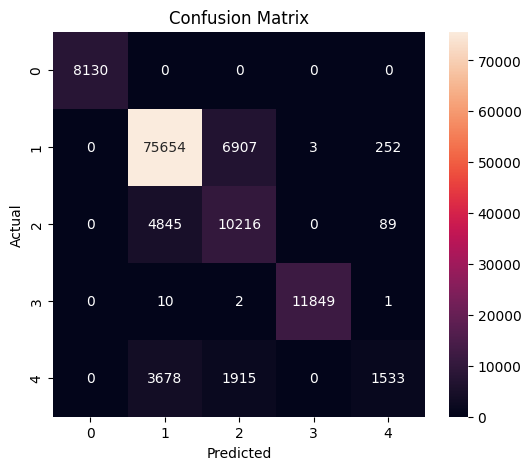

In [141]:

# 3. Create confusion matrix
cm = confusion_matrix(test_Y, y_pred)

# 4. Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()